In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:

w = model.coef_[0]          # Weights [w1, w2]
b = model.intercept_[0]     # Bias

print("Weight vector (w):", w)
print("Bias (b):", b)

Weight vector (w): [-0.11017399 -0.77608728]
Bias (b): -4.200363111845919


In [ ]:
# Function to calculate predictions using the explicit equation
def predict_manual(X, w, b):
    # w^T * x + b
    raw_scores = np.dot(X, w) + b
    # Classify as 1 if >= 0, else 0
    return np.where(raw_scores >= 0, 1, 0)

# Verify against sklearn's predict method
manual_preds = predict_manual(X_test, w, b)
print("Matches sklearn predictions:", np.array_equal(manual_preds, y_pred))

Matches sklearn predictions: True


In [ ]:
model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

SVC(kernel='linear')

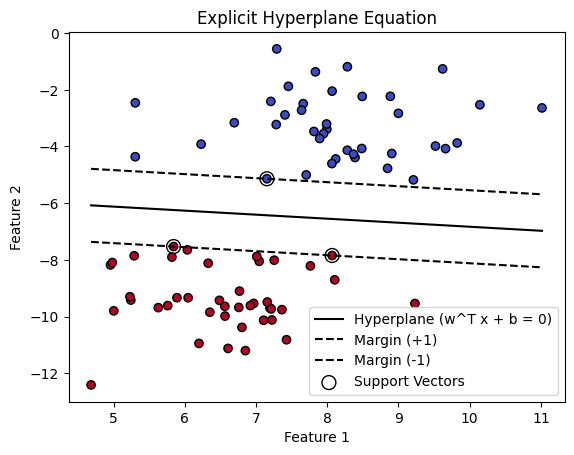

In [ ]:
# Generate range along x-axis
x1_vals = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)

# Rearranging w1*x1 + w2*x2 + b = 0  ==>  x2 = -(w1*x1 + b) / w2
hyperplane = -(w[0] * x1_vals + b) / w[1]
margin_plus = -(w[0] * x1_vals + b - 1) / w[1]   # w^T x + b = 1
margin_minus = -(w[0] * x1_vals + b + 1) / w[1]  # w^T x + b = -1

# Plot data points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')

# Plot boundary & margins
plt.plot(x1_vals, hyperplane, 'k-', label='Hyperplane (w^T x + b = 0)')
plt.plot(x1_vals, margin_plus, 'k--', label='Margin (+1)')
plt.plot(x1_vals, margin_minus, 'k--', label='Margin (-1)')

# Highlight support vectors
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='k', label='Support Vectors')

plt.title("Explicit Hyperplane Equation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()